Chapter 4<br>
Training Models


Linear Regression 
<br><br>
y = θ0 + θ1x1+ θ2x2+ ⋯ + θnxn
<br><br><br>
The Normal Equation<br>
θ = (XTX−1)XTy

In [3]:
import numpy as np
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 4 + 3*X + np.random.randn(100,1)

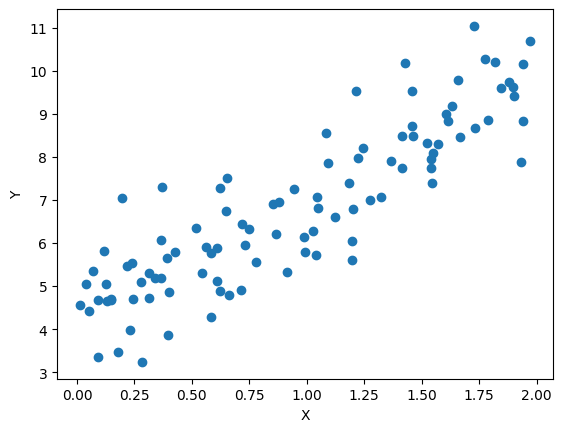

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Now let’s compute θusing the Normal Equation. We will use the inv() function from
NumPy’s Linear Algebra module (np.linalg) to compute the inverse of a matrix, and
the dot() method for matrix multiplication:

In [5]:
X_b=np.c_[np.ones((100,1)),X]  #adds X0 = 1 to each point in X
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) 

In [6]:
theta_best

array([[4.21509616],
       [2.77011339]])

It is close to the actual value the error is due to the noise added to the dataset

Now you can make predictions using θ:

In [7]:
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.21509616],
       [9.75532293]])

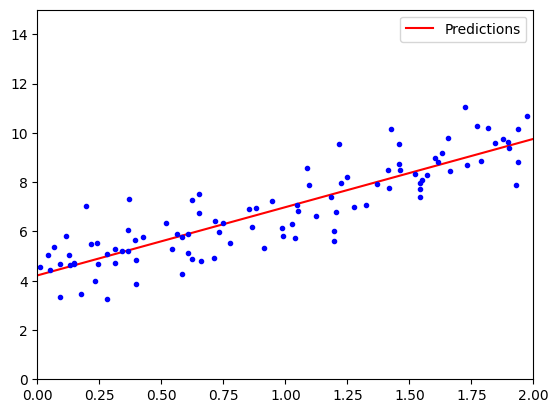

In [8]:
plt.plot(X_new,y_predict,"r-",label="Predictions")
plt.plot(X,y,"b.")
plt.legend()
plt.axis([0,2,0,15])
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X,y)
y_pred=model.predict(X_new)
model.intercept_, model.coef_

(array([4.21509616]), array([[2.77011339]]))

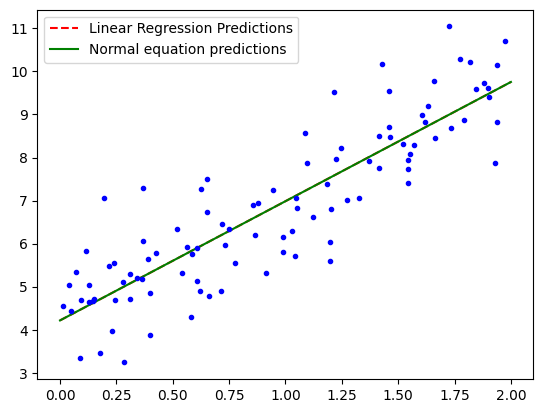

In [10]:
plt.plot(X_new,y_pred,"r--",label="Linear Regression Predictions")
plt.plot(X_new,y_predict,"g-",label = "Normal equation predictions")
plt.plot(X,y,"b.")
plt.legend()
plt.show()

It aligns perfectly!!!!

Curious to see how the normal equation acts on correlated features

In [11]:
X1 = np.random.rand(100,1)
X2= 2*X1

In [12]:
y = 4 + 3*X1 , 2*X2 + np.random.randn(100)

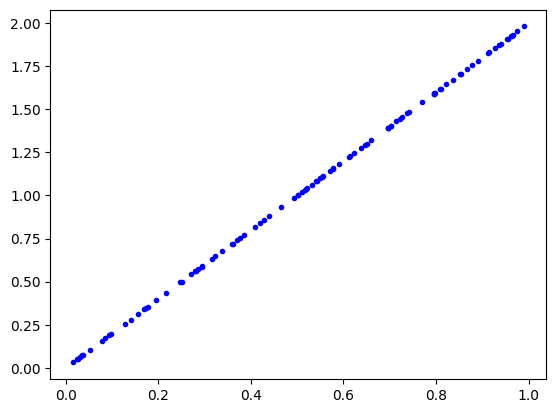

In [13]:
plt.plot(X1,X2,"b.")

In [14]:
X=np.c_[X1,X2]

In [15]:
#X_b=np.c_[np.ones((100,1)),X]  
#theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) 
# LinAlgError: Singular matrix

In [16]:
# model.fit(X,y)
#ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 100) + inhomogeneous part.

As expected